<a href="https://colab.research.google.com/github/RatchanonPa/Data-Warehouse-and-Big-Data-Analytics/blob/main/CRM_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPORTS

In [86]:
import numpy as np
import pandas as pd
import plotly.graph_objs as go
import plotly.offline as pyoff
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
import seaborn as sns
import nltk
import re
import pandas as pd
from nltk.corpus import stopwords
from wordcloud import WordCloud, STOPWORDS
import spacy
nltk.download('stopwords')
!python -m spacy download en_core_web_sm

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 59.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [87]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [88]:
import zipfile

# Path to your zip file in Google Drive
zip_file_path = '/content/drive/MyDrive/CRM ML/archive.zip'  # Replace with your actual path

# Destination directory for the extracted files
extract_path = '/content/drive/MyDrive/CRM ML/extracted_files/'  # Replace with your desired destination

try:
  with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
  print(f'Successfully extracted {zip_file_path} to {extract_path}')
except FileNotFoundError:
  print(f'Error: File not found at {zip_file_path}')
except zipfile.BadZipFile:
  print(f'Error: Invalid zip file at {zip_file_path}')
except Exception as e:
  print(f'An unexpected error occurred: {e}')


Successfully extracted /content/drive/MyDrive/CRM ML/archive.zip to /content/drive/MyDrive/CRM ML/extracted_files/


In [89]:
df = pd.read_csv('/content/drive/MyDrive/CRM ML/extracted_files/cell2celltrain.csv')
df.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

# CUSTOMER SEGMENTATION

In [91]:
df_segmentation = df
df_segmentation

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51042,3399958,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,6,No,0,60,No,1-Highest,Suburban,Other,Yes
51043,3399974,No,95.17,1745.0,85.0,0.99,45.0,4.7,122.0,15.9,...,0,9,No,1,60,No,3-Good,Other,Other,No
51044,3399978,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,7,No,1,80,No,5-Low,Other,Clerical,No
51045,3399990,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,9,No,0,30,No,5-Low,Other,Other,No


In [92]:
customer_per_MonthsInService = df_segmentation
customer_per_MonthsInService

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,0,9,No,1,10,No,1-Highest,Other,Professional,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51042,3399958,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,6,No,0,60,No,1-Highest,Suburban,Other,Yes
51043,3399974,No,95.17,1745.0,85.0,0.99,45.0,4.7,122.0,15.9,...,0,9,No,1,60,No,3-Good,Other,Other,No
51044,3399978,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,7,No,1,80,No,5-Low,Other,Clerical,No
51045,3399990,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0,9,No,0,30,No,5-Low,Other,Other,No


In [93]:
plot_data = [
    go.Histogram(
        x=customer_per_MonthsInService['MonthsInService']
    )
]

plot_layout = go.Layout(
        title='MonthsInService'
    )
fig = go.Figure(data=plot_data, layout=plot_layout)
pyoff.iplot(fig)

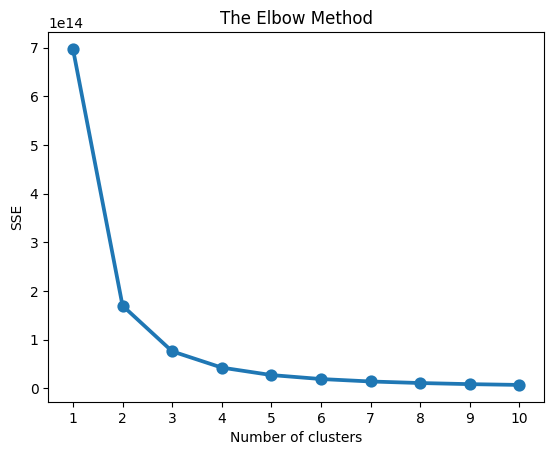

In [94]:
sse = {}
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, max_iter=1000, random_state=42).fit(customer_per_MonthsInService[['CustomerID', 'MonthsInService']])
    customer_per_MonthsInService["MonthsInServiceCluster"] = kmeans.labels_
    sse[k] = kmeans.inertia_ # SSE to closest cluster centroid
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
# Pass x and y as keyword arguments to sns.pointplot
sns.pointplot(x=list(sse.keys()), y=list(sse.values()))
plt.show()

In [95]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(customer_per_MonthsInService[['MonthsInService']])
customer_per_MonthsInService['MonthsInServiceCluster'] = kmeans.predict(customer_per_MonthsInService[['MonthsInService']])

In [96]:
def order_cluster(cluster_field_name, target_field_name,df,ascending):
    new_cluster_field_name = 'new_' + cluster_field_name
    df_new = df.groupby(cluster_field_name)[target_field_name].mean().reset_index()
    df_new = df_new.sort_values(by=target_field_name,ascending=ascending).reset_index(drop=True)
    df_new['index'] = df_new.index
    df_final = pd.merge(df,df_new[[cluster_field_name,'index']], on=cluster_field_name)
    df_final = df_final.drop([cluster_field_name],axis=1)
    df_final = df_final.rename(columns={"index":cluster_field_name})
    return df_final

In [97]:
df_segmentation_MonthsInService = order_cluster('MonthsInServiceCluster', 'MonthsInService', customer_per_MonthsInService,True)
df_segmentation_MonthsInService.groupby('MonthsInServiceCluster')['MonthsInService'].describe()

,count,mean,std,min,25%,50%,75%,max
MonthsInServiceCluster,,,,,,,,
0,27383.0,11.472008,3.090214,6.0,9.0,11.0,14.0,17.0
1,17785.0,23.417093,3.824434,18.0,20.0,23.0,26.0,31.0
2,5879.0,38.584793,6.258679,32.0,34.0,36.0,42.0,61.0


In [98]:
df_segmentation_MonthsInService

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus,MonthsInServiceCluster
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,...,4,No,0,30,Yes,1-Highest,Suburban,Professional,No,2
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,...,5,No,0,30,No,4-Medium,Suburban,Professional,Yes,2
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,...,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes,2
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,...,6,No,0,10,No,4-Medium,Other,Other,No,2
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,...,9,No,1,10,No,1-Highest,Other,Professional,Yes,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51042,3399958,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6,No,0,60,No,1-Highest,Suburban,Other,Yes,1
51043,3399974,No,95.17,1745.0,85.0,0.99,45.0,4.7,122.0,15.9,...,9,No,1,60,No,3-Good,Other,Other,No,1
51044,3399978,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7,No,1,80,No,5-Low,Other,Clerical,No,1
51045,3399990,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9,No,0,30,No,5-Low,Other,Other,No,1


In [99]:
df_churn_prone_customers = df_segmentation_MonthsInService[df_segmentation_MonthsInService['MonthsInServiceCluster'] == 0]

In [100]:
# 1st cluster: prone to churning
df_churn_prone_customers

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,...,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus,MonthsInServiceCluster
5593,3043654,No,97.11,441.0,60.0,0.00,144.0,0.0,-265.0,-43.1,...,2,No,0,130,No,7-Lowest,Suburban,Other,No,0
9625,3075822,No,32.89,96.0,50.0,0.25,0.0,0.0,46.0,14.2,...,5,No,0,Unknown,No,3-Good,Suburban,Other,Yes,0
9861,3077822,No,30.34,344.0,40.0,0.00,0.0,0.3,-101.0,-0.3,...,5,No,0,200,No,3-Good,Other,Other,Unknown,0
11377,3089738,No,29.85,685.0,10.0,0.00,36.0,10.9,-133.0,-19.5,...,6,No,0,Unknown,No,1-Highest,Other,Professional,Yes,0
12445,3098122,No,147.87,1786.0,95.0,0.00,224.0,0.0,233.0,4.9,...,0,No,0,Unknown,No,5-Low,Other,Other,Unknown,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49808,3390490,No,217.08,2299.0,46.0,0.25,442.0,0.4,1591.0,382.5,...,0,No,0,Unknown,No,4-Medium,Town,Other,Unknown,0
49809,3390518,No,55.23,377.0,45.0,1.24,38.0,0.0,-118.0,-15.2,...,8,No,0,Unknown,No,4-Medium,Rural,Professional,Yes,0
49810,3390522,No,41.94,376.0,41.0,0.25,0.0,0.2,39.0,-11.9,...,6,No,0,Unknown,No,3-Good,Suburban,Other,Unknown,0
49811,3390526,No,34.99,789.0,45.0,0.00,0.0,0.0,13.0,0.0,...,0,No,0,Unknown,No,2-High,Town,Other,Unknown,0


In [101]:
dataset = df_churn_prone_customers

In [102]:
# dataset shape
dataset.shape

(27383, 59)

In [103]:
# missing values
dataset.isnull().values.any()

True

In [104]:
# churn
dataset['Churn'].value_counts()

,count
Churn,
No,19545
Yes,7838


In [105]:
# missing values in churn column
dataset['Churn'].isna().sum()

0

In [106]:
# removing features that don't seem to have a lot of effect on the model
dataset = dataset.drop(['HandsetPrice', 'HandsetModels', 'Homeownership', 'MaritalStatus', 'UniqueSubs', 'PeakCallsInOut','OffPeakCallsInOut','DroppedBlockedCalls',
             'RetentionCalls','InboundCalls','OverageMinutes','ReceivedCalls', 'OwnsMotorcycle', 'NonUSTravel', 'OwnsComputer', 'RVOwner', 'TruckOwner', 'HandsetRefurbished',
             'HandsetWebCapable', 'Handsets'], axis=1)

In [107]:
dataset

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,...,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MonthsInServiceCluster
5593,3043654,No,97.11,441.0,60.0,0.00,0.0,-265.0,-43.1,19.0,...,No,No,0,2,0,No,7-Lowest,Suburban,Other,0
9625,3075822,No,32.89,96.0,50.0,0.25,0.0,46.0,14.2,1.7,...,No,No,0,5,0,No,3-Good,Suburban,Other,0
9861,3077822,No,30.34,344.0,40.0,0.00,0.3,-101.0,-0.3,0.0,...,No,No,0,5,0,No,3-Good,Other,Other,0
11377,3089738,No,29.85,685.0,10.0,0.00,10.9,-133.0,-19.5,0.0,...,No,No,0,6,0,No,1-Highest,Other,Professional,0
12445,3098122,No,147.87,1786.0,95.0,0.00,0.0,233.0,4.9,58.0,...,Yes,No,0,0,0,No,5-Low,Other,Other,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49808,3390490,No,217.08,2299.0,46.0,0.25,0.4,1591.0,382.5,9.0,...,No,No,0,0,0,No,4-Medium,Town,Other,0
49809,3390518,No,55.23,377.0,45.0,1.24,0.0,-118.0,-15.2,5.0,...,No,No,0,8,0,No,4-Medium,Rural,Professional,0
49810,3390522,No,41.94,376.0,41.0,0.25,0.2,39.0,-11.9,2.0,...,No,No,0,6,0,No,3-Good,Suburban,Other,0
49811,3390526,No,34.99,789.0,45.0,0.00,0.0,13.0,0.0,0.3,...,No,No,0,0,0,No,2-High,Town,Other,0


# PRE-PROCESSING DATASET

## Normalizing values

In [108]:
binary_cols=[]
multi_Value=[]
for col in dataset.columns :
    if dataset[col].dtype =='object':
        if dataset[col].unique().shape[0]==2:
            binary_cols.append(col)
        else:
            multi_Value.append(col)

In [109]:
binary_cols

['Churn',
 'ChildrenInHH',
 'BuysViaMailOrder',
 'RespondsToMailOffers',
 'OptOutMailings',
 'HasCreditCard',
 'NewCellphoneUser',
 'NotNewCellphoneUser',
 'MadeCallToRetentionTeam']

In [110]:
multi_Value

['ServiceArea', 'CreditRating', 'PrizmCode', 'Occupation']

In [111]:
# using label encoder for normalizing multi value columns
from sklearn.preprocessing import LabelEncoder
LE_cat = LabelEncoder()
for i in multi_Value:
    dataset[i] = LE_cat.fit_transform(dataset[i].astype(str))

In [112]:
dataset

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,...,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MonthsInServiceCluster
5593,3043654,No,97.11,441.0,60.0,0.00,0.0,-265.0,-43.1,19.0,...,No,No,0,2,0,No,6,2,3,0
9625,3075822,No,32.89,96.0,50.0,0.25,0.0,46.0,14.2,1.7,...,No,No,0,5,0,No,2,2,3,0
9861,3077822,No,30.34,344.0,40.0,0.00,0.3,-101.0,-0.3,0.0,...,No,No,0,5,0,No,2,0,3,0
11377,3089738,No,29.85,685.0,10.0,0.00,10.9,-133.0,-19.5,0.0,...,No,No,0,6,0,No,0,0,4,0
12445,3098122,No,147.87,1786.0,95.0,0.00,0.0,233.0,4.9,58.0,...,Yes,No,0,0,0,No,4,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49808,3390490,No,217.08,2299.0,46.0,0.25,0.4,1591.0,382.5,9.0,...,No,No,0,0,0,No,3,3,3,0
49809,3390518,No,55.23,377.0,45.0,1.24,0.0,-118.0,-15.2,5.0,...,No,No,0,8,0,No,3,1,4,0
49810,3390522,No,41.94,376.0,41.0,0.25,0.2,39.0,-11.9,2.0,...,No,No,0,6,0,No,2,2,3,0
49811,3390526,No,34.99,789.0,45.0,0.00,0.0,13.0,0.0,0.3,...,No,No,0,0,0,No,1,3,3,0


In [113]:
dataset.shape

(27383, 39)

In [114]:
# using get dummies for normalizing binary value columns
Binary_cols_except_churn=binary_cols[1:]
dataset_yes_no=dataset[Binary_cols_except_churn]
dataset_yes_no

,ChildrenInHH,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,HasCreditCard,NewCellphoneUser,NotNewCellphoneUser,MadeCallToRetentionTeam
5593,No,No,No,No,Yes,No,No,No
9625,No,Yes,Yes,No,Yes,No,No,No
9861,No,No,No,No,Yes,No,No,No
11377,Yes,Yes,Yes,No,Yes,No,No,No
12445,No,No,No,No,No,Yes,No,No
...,...,...,...,...,...,...,...,...
49808,No,No,No,No,No,No,No,No
49809,No,Yes,Yes,No,Yes,No,No,No
49810,Yes,Yes,Yes,No,Yes,No,No,No
49811,No,No,No,No,No,No,No,No


In [115]:
dfDummies = pd.get_dummies(dataset_yes_no, prefix = dataset_yes_no.columns)
dfDummies.shape

(27383, 16)

In [116]:
dataset.shape

(27383, 39)

In [117]:
removed_binary_cols=dataset.drop(binary_cols,axis=1)
removed_binary_cols

,CustomerID,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,...,AgeHH1,AgeHH2,RetentionOffersAccepted,ReferralsMadeBySubscriber,IncomeGroup,AdjustmentsToCreditRating,CreditRating,PrizmCode,Occupation,MonthsInServiceCluster
5593,3043654,97.11,441.0,60.0,0.00,0.0,-265.0,-43.1,19.0,2.0,...,0.0,0.0,0,0,2,0,6,2,3,0
9625,3075822,32.89,96.0,50.0,0.25,0.0,46.0,14.2,1.7,1.3,...,52.0,24.0,0,0,5,0,2,2,3,0
9861,3077822,30.34,344.0,40.0,0.00,0.3,-101.0,-0.3,0.0,0.0,...,44.0,0.0,0,0,5,0,2,0,3,0
11377,3089738,29.85,685.0,10.0,0.00,10.9,-133.0,-19.5,0.0,0.0,...,28.0,30.0,0,0,6,0,0,0,4,0
12445,3098122,147.87,1786.0,95.0,0.00,0.0,233.0,4.9,58.0,9.3,...,0.0,0.0,0,0,0,0,4,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49808,3390490,217.08,2299.0,46.0,0.25,0.4,1591.0,382.5,9.0,1.3,...,0.0,0.0,0,0,0,0,3,3,3,0
49809,3390518,55.23,377.0,45.0,1.24,0.0,-118.0,-15.2,5.0,5.7,...,50.0,50.0,0,0,8,0,3,1,4,0
49810,3390522,41.94,376.0,41.0,0.25,0.2,39.0,-11.9,2.0,0.0,...,44.0,40.0,0,0,6,0,2,2,3,0
49811,3390526,34.99,789.0,45.0,0.00,0.0,13.0,0.0,0.3,0.3,...,0.0,0.0,0,0,0,0,1,3,3,0


In [118]:
clean_dataframe = pd.concat([removed_binary_cols, dfDummies, dataset['Churn']], axis=1)

# Replace values without using inplace=True
clean_dataframe['Churn'] = clean_dataframe['Churn'].replace({'Yes': 1, 'No': 0})


<ipython-input-118-6fead477dc3e>:4: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [119]:
clean_dataframe

,CustomerID,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,...,OptOutMailings_Yes,HasCreditCard_No,HasCreditCard_Yes,NewCellphoneUser_No,NewCellphoneUser_Yes,NotNewCellphoneUser_No,NotNewCellphoneUser_Yes,MadeCallToRetentionTeam_No,MadeCallToRetentionTeam_Yes,Churn
5593,3043654,97.11,441.0,60.0,0.00,0.0,-265.0,-43.1,19.0,2.0,...,False,False,True,True,False,True,False,True,False,0
9625,3075822,32.89,96.0,50.0,0.25,0.0,46.0,14.2,1.7,1.3,...,False,False,True,True,False,True,False,True,False,0
9861,3077822,30.34,344.0,40.0,0.00,0.3,-101.0,-0.3,0.0,0.0,...,False,False,True,True,False,True,False,True,False,0
11377,3089738,29.85,685.0,10.0,0.00,10.9,-133.0,-19.5,0.0,0.0,...,False,False,True,True,False,True,False,True,False,0
12445,3098122,147.87,1786.0,95.0,0.00,0.0,233.0,4.9,58.0,9.3,...,False,True,False,False,True,True,False,True,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49808,3390490,217.08,2299.0,46.0,0.25,0.4,1591.0,382.5,9.0,1.3,...,False,True,False,True,False,True,False,True,False,0
49809,3390518,55.23,377.0,45.0,1.24,0.0,-118.0,-15.2,5.0,5.7,...,False,False,True,True,False,True,False,True,False,0
49810,3390522,41.94,376.0,41.0,0.25,0.2,39.0,-11.9,2.0,0.0,...,False,False,True,True,False,True,False,True,False,0
49811,3390526,34.99,789.0,45.0,0.00,0.0,13.0,0.0,0.3,0.3,...,False,True,False,True,False,True,False,True,False,0


## Imputation preserves all cases by replacing missing data with an estimated value based on other available information.

In [120]:
from sklearn.impute import KNNImputer
imputer = KNNImputer(n_neighbors=5)
final_dataset = pd.DataFrame(imputer.fit_transform(clean_dataframe),columns = clean_dataframe.columns)

In [121]:
bar_df=final_dataset.isna().sum()
bar_df[bar_df>0]

,0


# CUSTOMER CHURN

## XG Boost

In [122]:
!pip install xgboost==1.7.5  # Replace with the desired version

In [123]:
from sklearn.model_selection import train_test_split
y = final_dataset["Churn"]
X = final_dataset.drop(["Churn", 'CustomerID'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20, random_state=42)

In [124]:
from xgboost.sklearn import XGBClassifier
xgb_model = XGBClassifier().fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)

In [125]:
print(xgb_model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None,
              predictor=None, random_state=None, ...)


In [126]:
model = xgb_model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [127]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

         0.0       0.74      0.91      0.82      3876
         1.0       0.52      0.23      0.31      1601

    accuracy                           0.71      5477
   macro avg       0.63      0.57      0.57      5477
weighted avg       0.68      0.71      0.67      5477



## Decision tree

In [128]:
y = final_dataset["Churn"]
X = final_dataset.drop(["Churn", 'CustomerID'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20, random_state=42)

In [129]:
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier(criterion='entropy', random_state=1)
DT.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=1)

In [130]:
prediction = DT.predict(X_test)

In [131]:
print(classification_report(y_test,prediction))

              precision    recall  f1-score   support

         0.0       0.75      0.74      0.75      3876
         1.0       0.39      0.39      0.39      1601

    accuracy                           0.64      5477
   macro avg       0.57      0.57      0.57      5477
weighted avg       0.64      0.64      0.64      5477



## Stochastic gradient descent

In [132]:
y = final_dataset["Churn"]
X = final_dataset.drop(["Churn", 'CustomerID'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20, random_state=42)

In [133]:
from sklearn.linear_model import SGDClassifier
SGDC = SGDClassifier()
SGDC.fit(X_train, y_train)

SGDClassifier()

In [134]:
predictions = SGDC.predict(X_test)

In [135]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

         0.0       0.72      0.95      0.82      3876
         1.0       0.43      0.09      0.14      1601

    accuracy                           0.70      5477
   macro avg       0.57      0.52      0.48      5477
weighted avg       0.63      0.70      0.62      5477



## Logistic regression

In [136]:
y = final_dataset["Churn"]
X = final_dataset.drop(["Churn", 'CustomerID'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.20, random_state=42)

In [137]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
classifier = LogisticRegression(max_iter=4000)
classifier.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression(max_iter=4000)

In [138]:
predictions = classifier.predict(X_test)

In [139]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

         0.0       0.71      0.99      0.83      3876
         1.0       0.55      0.03      0.06      1601

    accuracy                           0.71      5477
   macro avg       0.63      0.51      0.45      5477
weighted avg       0.67      0.71      0.60      5477



# Sentiment Analysis

In [140]:
twit = pd.read_csv('/content/drive/MyDrive/CRM ML/Twitter Scraping Tweets Dataset.csv')
twit.head()

,Unnamed: 0,user_name,user_location,user_description,user_verified,date,text,hashtags,source,label
0,0,Aravindh S,"Tamil Nadu, India",Nemophilist 🌎 90's KID 😉 😜,False,14-03-2022 12:38,And I am hearing new stories that within a sma...,NaN,Twitter for iPhone,0
1,1,Gbest Bulk SMS,Abuja Nigeria,Providers of Bulk SMS | Data Bundle | Airtime ...,False,14-03-2022 12:21,Do U have excess Airtime in ur line and will l...,NaN,Twitter for Android,neutral
2,2,Kalyanashis Mahanty,"Barabhum , West Bengal, India",School teacher by profession and I am everythi...,False,14-03-2022 12:05,@airtelindia @Airtel_Presence bye bye for now....,NaN,Twitter for Android,0
3,3,"Network Palava - Free, Cheap Data Daily.","Lagos, Nigeria","Get Cheap, Free Browsing Solutions at https://...",False,14-03-2022 11:59,Working NapsternetV Configuration Files Downlo...,['mtn'],Revive Social App,neutral
4,4,JayRoy 🇮🇳,NaN,Proud Indian \n\n(RT's r not endorsements),False,14-03-2022 11:55,@airtelnews @airtelindia @Airtel_Presence @air...,NaN,Twitter Web App,0


In [141]:
twit = twit.drop(['user_name', 'user_location', 'user_description', 'user_verified', 'date', 'hashtags', 'source'], axis=1)
twit = twit[twit['label'] != 'neutral']
twit = twit.replace(np.nan, '', regex=True)

In [142]:
twit.head()

,Unnamed: 0,text,label
0,0,And I am hearing new stories that within a sma...,0
2,2,@airtelindia @Airtel_Presence bye bye for now....,0
4,4,@airtelnews @airtelindia @Airtel_Presence @air...,0
5,5,@Airtel_Presence @WynkMusic @PawanKalyan @iams...,0
6,6,"Designed with ultimate sophistication, curated...",1


In [143]:
twit['label'].value_counts()

,count
label,
,334
0,81
1,18


In [144]:
# Load the 'en_core_web_sm' model
nlp = spacy.load("en_core_web_sm", disable=['parser', 'ner'])

In [145]:
twit['text'] = twit['text'].apply(lambda x: " ".join(x.lower() for x in x.split()))
twit['text'] = twit['text'].str.replace('[^\w\s]','')
stop = stopwords.words('english')
twit['text'] = twit['text'].apply(lambda x: " ".join(x for x in x.split() if x not in stop))

In [146]:
def space(comment):
    doc = nlp(comment)
    return " ".join([token.lemma_ for token in doc])

In [147]:
twit['text']= twit['text'].apply(space)

In [148]:
twit.head()

,Unnamed: 0,text,label
0,0,hear new story within small 2bhk house need us...,0
2,2,@airtelindia @airtel_presence bye bye now . ba...,0
4,4,@airtelnews @airtelindia @airtel_presence @air...,0
5,5,@airtel_presence @wynkmusic @pawankalyan @iams...,0
6,6,"design ultimate sophistication , curate love ,...",1


In [149]:
from sklearn.feature_extraction.text import CountVectorizer
from nltk.tokenize import RegexpTokenizer
token = RegexpTokenizer(r'[a-zA-Z0-9]+')
cv = CountVectorizer(stop_words='english',ngram_range = (1,1),tokenizer = token.tokenize)
text_counts = cv.fit_transform(twit['text'])

/usr/local/lib/python3.10/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning:

The parameter 'token_pattern' will not be used since 'tokenizer' is not None'



In [150]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(text_counts, twit['label'], test_size=0.25, random_state=5)

In [151]:
from sklearn.naive_bayes import MultinomialNB
MNB = MultinomialNB()
MNB.fit(X_train, Y_train)

MultinomialNB()

In [152]:
predicted = MNB.predict(X_test)

In [153]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
print(confusion_matrix(Y_test,predicted))
print(classification_report(Y_test,predicted))
print("Accuracy: ", accuracy_score(Y_test, predicted))

[[73 10  4]
 [11  7  1]
 [ 3  0  0]]
              precision    recall  f1-score   support

                   0.84      0.84      0.84        87
           0       0.41      0.37      0.39        19
           1       0.00      0.00      0.00         3

    accuracy                           0.73       109
   macro avg       0.42      0.40      0.41       109
weighted avg       0.74      0.73      0.74       109

Accuracy:  0.7339449541284404


In [154]:
from sklearn.linear_model import SGDClassifier
SGDC = SGDClassifier()
SGDC.fit(X_train, Y_train)

SGDClassifier()

In [155]:
predictions = SGDC.predict(X_test)

In [156]:
print(confusion_matrix(Y_test,predictions))
print(classification_report(Y_test,predictions))
print("Accuracy: ", accuracy_score(Y_test, predictions))

[[77  8  2]
 [14  5  0]
 [ 3  0  0]]
              precision    recall  f1-score   support

                   0.82      0.89      0.85        87
           0       0.38      0.26      0.31        19
           1       0.00      0.00      0.00         3

    accuracy                           0.75       109
   macro avg       0.40      0.38      0.39       109
weighted avg       0.72      0.75      0.73       109

Accuracy:  0.7522935779816514


In [157]:
from sklearn.tree import DecisionTreeClassifier
DT = DecisionTreeClassifier(criterion='entropy', random_state=1)
DT.fit(X_train, Y_train)

DecisionTreeClassifier(criterion='entropy', random_state=1)

In [158]:
prediction = DT.predict(X_test)

In [159]:
print(confusion_matrix(Y_test,prediction))
print(classification_report(Y_test,prediction))
print("Accuracy: ", accuracy_score(Y_test, prediction))

[[75 10  2]
 [13  6  0]
 [ 2  1  0]]
              precision    recall  f1-score   support

                   0.83      0.86      0.85        87
           0       0.35      0.32      0.33        19
           1       0.00      0.00      0.00         3

    accuracy                           0.74       109
   macro avg       0.40      0.39      0.39       109
weighted avg       0.73      0.74      0.73       109

Accuracy:  0.7431192660550459


In [160]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(twit.text, twit.label, test_size=0.2, random_state=32)

In [161]:
from sklearn.feature_extraction.text import TfidfVectorizer
# Create feature vectors
vectorizer = TfidfVectorizer(min_df = 5,
                             max_df = 0.8,
                             sublinear_tf = True,
                             use_idf = True)
train_vectors = vectorizer.fit_transform(X_train)
test_vectors = vectorizer.transform(X_test)

In [162]:
from sklearn import svm
from sklearn.metrics import classification_report
classifier_linear = svm.SVC(kernel='linear')
classifier_linear.fit(train_vectors, y_train)
prediction_linear = classifier_linear.predict(test_vectors)

In [163]:
print(classification_report(y_test,prediction_linear))

              precision    recall  f1-score   support

                   0.78      0.99      0.87        68
           0       0.00      0.00      0.00        13
           1       0.00      0.00      0.00         6

    accuracy                           0.77        87
   macro avg       0.26      0.33      0.29        87
weighted avg       0.61      0.77      0.68        87



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



In [164]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
vectorizer.fit(X_train)

CountVectorizer()

In [165]:
X_train = vectorizer.transform(X_train)
X_test= vectorizer.transform(X_test)

In [166]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [167]:
predictions = classifier.predict(X_test)

In [168]:
print(confusion_matrix(y_test,predictions))
print(classification_report(y_test,predictions))
print("Accuracy: ", accuracy_score(y_test, predictions))

[[62  6  0]
 [10  3  0]
 [ 6  0  0]]
              precision    recall  f1-score   support

                   0.79      0.91      0.85        68
           0       0.33      0.23      0.27        13
           1       0.00      0.00      0.00         6

    accuracy                           0.75        87
   macro avg       0.38      0.38      0.37        87
weighted avg       0.67      0.75      0.70        87

Accuracy:  0.7471264367816092


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

